# Assignment 3

Deadline: 22.04.2026 12:00 CET

- Gallo Alessandro , 25-732-140 , alessandro.gallo2@uzh.ch
- Maruccio Anna , 25-742-800 , anna.maruccio@uzh.ch
- Perbellini Cesare, 25-741-257, cesare.perbellini@uzh.ch
- Venturi Matilde , 25-741-059 , matilde.venturi@uzh.ch

## Prerequisites: Library imports, data load and initialization of the backtest service

In [1]:
# Standard library imports
import os
import sys
import copy
from pathlib import Path
from typing import Optional


# Third party imports
import numpy as np
import pandas as pd

# Add the project root directory to Python path
# Resolve the repo root from whatever folder opened the notebook.
def find_repo_root(start_path: Path) -> Path:
    for candidate in (start_path.resolve(), *start_path.resolve().parents):
        if (candidate / 'src').exists() and (candidate / 'data').exists():
            return candidate
        nested_repo = candidate / 'qpmwp-course'
        if (nested_repo / 'src').exists() and (nested_repo / 'data').exists():
            return nested_repo
    raise FileNotFoundError('Could not locate the qpmwp-course repository root from the current working directory.')

repo_root = find_repo_root(Path.cwd())
project_root = str(repo_root)
src_path = repo_root / 'src'
data_path = repo_root / 'data'
assignment_data_path = repo_root / 'data_backtesting_assignment3'

if str(repo_root) not in sys.path:
    sys.path.append(str(repo_root))
if str(src_path) not in sys.path:
    sys.path.append(str(src_path))


# Local modules imports
from helper_functions import (
    # load_pickle,
    load_data_spi,
)
from estimation.covariance import Covariance
from estimation.expected_return import ExpectedReturn
from optimization.constraints import Constraints
from optimization.optimization_data import OptimizationData
from optimization.optimization import (
    Optimization,
    Objective,
    MeanVariance,
)
from backtesting.backtest_item_builder.bib_classes import (
    SelectionItemBuilder,
    OptimizationItemBuilder,
)
from backtesting.backtest_item_builder.bibfn_selection import (
    bibfn_selection_min_volume,
    bibfn_selection_gaps,
)
from backtesting.backtest_item_builder.bibfn_optimization_data import (
    bibfn_return_series,
)
from backtesting.backtest_item_builder.bibfn_constraints import (
    bibfn_budget_constraint,
    bibfn_box_constraints,
    bibfn_size_dependent_upper_bounds,
)
from backtesting.backtest_data import BacktestData
from backtesting.backtest_service import BacktestService
from backtesting.backtest import Backtest



In [2]:

# Keep the assignment data path relative to the repo so this runs on any machine.
PATH_TO_DATA = assignment_data_path

if not PATH_TO_DATA.exists():
    raise FileNotFoundError(f'Could not find the assignment data folder: {PATH_TO_DATA}')


In [3]:
# Load market and jkp data from parquet files
import pyarrow.parquet as pq

table_market = pq.read_table(PATH_TO_DATA / 'market_data.parquet')
table_jkp = pq.read_table(PATH_TO_DATA / 'jkp_data.parquet')

market_data = table_market.to_pandas(strings_to_categorical=False)
jkp_data = table_jkp.to_pandas(strings_to_categorical=False) #dati per costruire factors 

# -------------------------
# First, ensure that market data and jkp data 
# have the same dates by forward filling the market data for the missing dates.
# -------------------------

market_data_dates = (
    market_data
    .index.get_level_values('date')
    .unique().sort_values()
)
jkp_data_dates = (
    jkp_data
    .index.get_level_values('date')
    .unique().sort_values()
)

# Find the jkp_data_dates which are not in the market_data_dates
missing_dates = jkp_data_dates[~jkp_data_dates.isin(market_data_dates)]

# Extend the market data for the missing dates using the last available market data (i.e., forward fill).
tmp_dict = {}
for date in missing_dates:
    last_date = market_data_dates[market_data_dates <= date][-1]
    tmp_dict[date] = market_data.loc[last_date]
    
df_missing = pd.concat(tmp_dict, axis=0)
df_missing.index.names = market_data.index.names
market_data_ffill = pd.concat([market_data, df_missing]).sort_index()


# -------------------------
# Define rebalancing dates
# -------------------------

n_month = 3 # We want to rebalance every n_month months

# We want to use the dates from the jkp data for rebalancing, 
# since they are less frequent than the market data dates.
rebdates = (
    jkp_data_dates[
        jkp_data_dates > market_data_dates[0]
    ][::n_month]
    .strftime('%Y-%m-%d').tolist()
)
# Drop the first rebalancing dates which are before 2002-01-01, 
# because of poor data coverage.
rebdates = [date for date in rebdates if date > '2002-01-01']


# -------------------------
# Instantiate the BacktestData class
# and set the market, jkp, and benchmark data as attributes
# -------------------------

data = BacktestData()
data.market_data = market_data_ffill  # notice that we use the forward filled market data here
data.jkp_data = jkp_data
data.bm_series = load_data_spi(path=str(data_path))

In [4]:
# Define the selection item builders.
selection_item_builders = {
    'gaps': SelectionItemBuilder(
        bibfn=bibfn_selection_gaps,
        width=365 * 3,
        n_days=10,
    ),
    'min_volume': SelectionItemBuilder(
        bibfn=bibfn_selection_min_volume,
        width=365 * 3,
        min_volume=500_000,
        agg_fn=np.median,
    ),
}

# Define the optimization item builders.
optimization_item_builders = {
    'return_series': OptimizationItemBuilder(
        bibfn=bibfn_return_series,
        width=365 * 3,
        fill_value=0,
    ),
    'budget_constraint': OptimizationItemBuilder(
        bibfn=bibfn_budget_constraint,
        budget=1
    ),
    'box_constraints': OptimizationItemBuilder(
        bibfn=bibfn_box_constraints,
        upper=0.1
    ),
    'size_dep_upper_bounds': OptimizationItemBuilder(
        bibfn = bibfn_size_dependent_upper_bounds,
        small_cap = {'threshold': 300_000_000, 'upper': 0.02},
        mid_cap = {'threshold': 1_000_000_000, 'upper': 0.05},
        large_cap = {'threshold': 10_000_000_000, 'upper': 0.1},
    ),
}

# Initialize the backtest service
bs = BacktestService(
    data=data,
    selection_item_builders=selection_item_builders,
    optimization_item_builders=optimization_item_builders,
    rebdates=rebdates,
)

## 1. Maximum Sharpe Ratio Portfolio

a) 

(6 points)

Complete the `MaxSharpe` class below by implementing its methods `set_objective` and `solve`.
The `solve` method should implement an iterative algorithm that quickly approximates the "true" maximimum Sharpe ratio portfolio (given the estimates of mean and covariance). This approximation should be done by repeatedly solving a mean-variance optimization problem, where the risk aversion parameter (which scales the covariance matrix) is adjusted in each iteration. The algorithm should terminate after a maximum of 10 iterations. 

### Theory Behind the Maximum Sharpe Ratio Portfolio

The Sharpe ratio measures return per unit of risk.  
If the risk-free rate is ignored, the Sharpe ratio of a portfolio with weights $w$ is

$$
\text{SR}(w) = \frac{\mu^\top w}{\sqrt{w^\top \Sigma w}},
$$

where $\mu$ is the expected return vector and $\Sigma$ is the covariance matrix.

The goal of the maximum Sharpe ratio portfolio is to choose $w$ that maximizes this ratio subject to the portfolio constraints.

Since this is a ratio, it is harder to solve directly than a standard quadratic problem.  
A practical approach is to solve instead

$$
\min_w \left( -\mu^\top w + \frac{\lambda}{2} w^\top \Sigma w \right),
$$

for a given risk-aversion parameter $\lambda$.

For the unconstrained tangency portfolio, the first-order condition is

$$
-\mu + \lambda \Sigma w = 0,
$$

which implies

$$
\lambda = \frac{\mu^\top w}{w^\top \Sigma w}.
$$

This motivates the iterative algorithm used here:

1. Start from an initial value of $\lambda$.
2. Solve the mean-variance problem under the portfolio constraints.
3. Compute the implied value of $\lambda$ using

$$
\lambda_{\text{new}} = \frac{\mu^\top w}{w^\top \Sigma w}.
$$

4. Repeat until $\lambda$ stops changing.

At convergence, the assumed and implied values of $\lambda$ are consistent.  
With constraints, this should be interpreted as an iterative approximation of the maximum Sharpe ratio portfolio, based on the tangency condition from the unconstrained case.


In [5]:
class MaxSharpe(Optimization):

    def __init__(self,
                 constraints: Optional[Constraints] = None,
                 covariance: Optional[Covariance] = None,
                 expected_return: Optional[ExpectedReturn] = None,
                 **kwargs) -> None:
        super().__init__(
            constraints=constraints,
            **kwargs,
        )
        self.covariance = Covariance() if covariance is None else covariance
        self.expected_return = ExpectedReturn() if expected_return is None else expected_return

    def set_objective(self, optimization_data: OptimizationData) -> None:
        X = optimization_data['return_series']

        # Estimate and cache mu and Sigma once for this rebalance window.
        # solve() only needs to update lambda on top of these inputs.
        self._covmat = np.asarray(
            self.covariance.estimate(X=X, inplace=False),
            dtype=float,
        )
        self._mu = np.asarray(
            self.expected_return.estimate(X=X, inplace=False),
            dtype=float,
        ).reshape(-1)

        risk_aversion = float(self.params.get('risk_aversion', 1.0))

        # qpsolvers minimizes 0.5 * w'Pw + q'w.
        # For the assignment objective, that means q = -mu and P = lambda * Sigma.
        self.objective = Objective(
            q=-self._mu,
            P=risk_aversion * self._covmat,
        )
        return None

    def solve(self) -> None:
        # Solve the tangency portfolio with a fixed-point update on lambda.
        # Each iteration solves a mean-variance problem, then refreshes lambda
        # from the portfolio it just produced.
        max_iter = int(self.params.get('max_iter', 10))
        tol = float(self.params.get('tol', 1e-8))
        risk_aversion = float(self.params.get('risk_aversion', 1.0))

        mu = self._mu
        covmat = self._covmat

        # Keep the full iteration trace and the best portfolio seen so far.
        history = []
        best_results = None
        best_sharpe = -np.inf
        best_risk_aversion = risk_aversion
        best_iteration = None

        for iteration in range(max_iter):
            # Rebuild the quadratic objective with the current lambda.
            self.objective = Objective(
                q=-mu,
                P=risk_aversion * covmat,
            )

            super().solve()
            current_results = copy.deepcopy(self.results)

            # Align solver weights with the asset order used by mu and Sigma.
            w = (
                pd.Series(current_results['weights'])
                .reindex(self.constraints.ids)
                .fillna(0.0)
                .to_numpy(dtype=float)
            )

            # Measure the portfolio the solver produced under the current lambda.
            port_return = float(mu @ w)
            port_var = float(w @ covmat @ w)

            # Stop if variance is not usable, since Sharpe would be undefined.
            if port_var <= 0:
                break

            sharpe = port_return / np.sqrt(port_var)
            history.append(
                {
                    'iteration': iteration,
                    'risk_aversion': risk_aversion,
                    'expected_return': port_return,
                    'variance': port_var,
                    'sharpe': sharpe,
                }
            )

            # Keep the best iterate, not just the last one.
            if sharpe > best_sharpe:
                best_sharpe = sharpe
                best_results = current_results
                best_risk_aversion = risk_aversion
                best_iteration = iteration

            # At the tangency portfolio, lambda = (mu'w) / (w'Sigma w).
            # Feed that implied lambda into the next solve.
            new_risk_aversion = port_return / port_var

            # Stop once lambda has effectively stopped moving.
            if abs(new_risk_aversion - risk_aversion) <= tol * max(1.0, abs(risk_aversion)):
                break

            risk_aversion = new_risk_aversion

        if best_results is None:
            raise RuntimeError('MaxSharpe did not produce a valid iterate.')

        # Store the best solution and its diagnostics for later inspection.
        self.params['risk_aversion'] = best_risk_aversion
        self.results = best_results
        self.results['risk_aversion'] = best_risk_aversion
        self.results['best_iteration'] = best_iteration
        self.results['best_sharpe'] = best_sharpe
        self.results['history'] = pd.DataFrame(history)

        return None

b) 

(2 points)

Provide either a theoretical or an empirical justification that your algorithm converges to the true maximum Sharpe ratio portfolio for the given coefficients of mean and covariance.
Hint: If you want to provide an empirical justification, you can perform an optimization for a single point in time by running the following code.

In [6]:
# Compare the iterative MaxSharpe solution with a grid search over fixed lambda values.
# Both methods are evaluated on the same rebalance snapshot.

comparison_rebdate = rebdates[-1]
comparison_solver = "cvxopt"
lambda_grid = np.geomspace(1e-2, 1e2, 60)

bs_cmp = BacktestService(
    data=data,
    selection_item_builders=copy.deepcopy(selection_item_builders),
    optimization_item_builders=copy.deepcopy(optimization_item_builders),
    rebdates=rebdates,
    quiet=True,
)
bs_cmp.optimization = MaxSharpe(
    covariance=Covariance(method="pearson"),
    expected_return=ExpectedReturn(method="geometric"),
    solver_name=comparison_solver,
)
bs_cmp.prepare_rebalancing(comparison_rebdate)

base_constraints = copy.deepcopy(bs_cmp.optimization.constraints)
base_data = copy.deepcopy(bs_cmp.optimization_data)

def solve_maxsharpe(lambda_value, *, max_iter):
    # max_iter=10 runs the fixed-point iteration.
    # max_iter=1 returns the single mean-variance solution for that lambda.
    opt = MaxSharpe(
        constraints=copy.deepcopy(base_constraints),
        covariance=Covariance(method="pearson"),
        expected_return=ExpectedReturn(method="geometric"),
        solver_name=comparison_solver,
        risk_aversion=float(lambda_value),
        max_iter=max_iter,
        tol=1e-8,
    )
    opt.set_objective(copy.deepcopy(base_data))
    opt.solve()

    # Rebuild a dense weight vector so all portfolio metrics use the same asset order.
    w = (
        pd.Series(opt.results["weights"])
        .reindex(opt.constraints.ids)
        .fillna(0.0)
        .to_numpy(dtype=float)
    )

    mu = opt._mu
    cov = opt._covmat
    port_return = float(mu @ w)
    port_var = float(w @ cov @ w)
    sharpe = port_return / np.sqrt(port_var)

    return {
        "lambda": float(opt.results.get("risk_aversion", lambda_value)),
        "weights": w,
        "return": port_return,
        "variance": port_var,
        "sharpe": sharpe,
    }

# Iterative solution.
iter_result = solve_maxsharpe(1.0, max_iter=10)

# Empirical benchmark: evaluate a grid of fixed lambda values.
grid_rows = []
for lam in lambda_grid:
    res = solve_maxsharpe(lam, max_iter=1)
    grid_rows.append({
        "lambda": float(lam),
        "sharpe": res["sharpe"],
        "return": res["return"],
        "variance": res["variance"],
    })

grid_df = pd.DataFrame(grid_rows).sort_values("lambda").reset_index(drop=True)
best_grid_lambda = float(grid_df.loc[grid_df["sharpe"].idxmax(), "lambda"])
best_grid_result = solve_maxsharpe(best_grid_lambda, max_iter=1)


Rebalance date: 2024-01-31
Iterative method -> lambda = 5.950039, Sharpe = 0.063581
Best grid point   -> lambda = 6.020894, Sharpe = 0.063581
L1 distance between weights = 0.002589


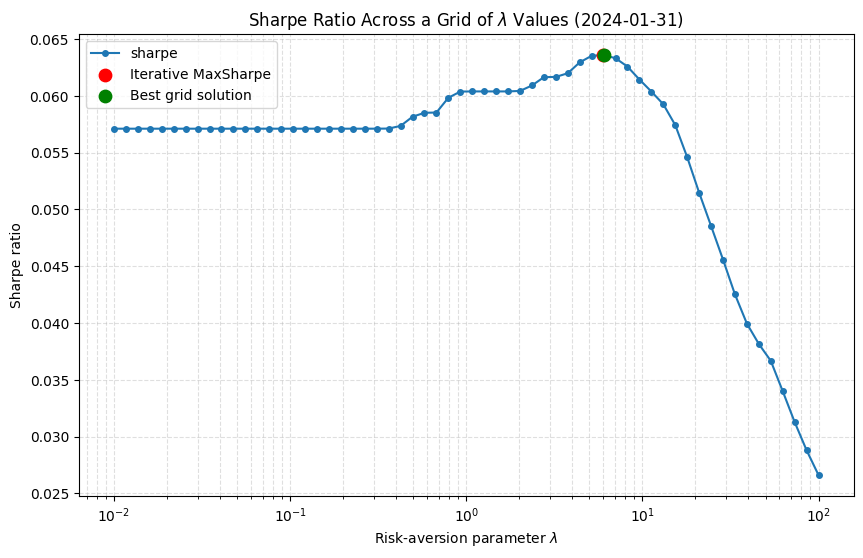

In [7]:
# Compare the two solutions numerically and visually.
weight_gap_l1 = np.abs(iter_result["weights"] - best_grid_result["weights"]).sum()

print(f"Rebalance date: {comparison_rebdate}")
print(f"Iterative method -> lambda = {iter_result['lambda']:.6f}, Sharpe = {iter_result['sharpe']:.6f}")
print(f"Best grid point   -> lambda = {best_grid_result['lambda']:.6f}, Sharpe = {best_grid_result['sharpe']:.6f}")
print(f"L1 distance between weights = {weight_gap_l1:.6f}")

ax = grid_df.plot(
    x="lambda",
    y="sharpe",
    logx=True,
    figsize=(10, 6),
    marker="o",
    markersize=4,
    linewidth=1.5,
    title=f"Sharpe Ratio Across a Grid of $\\lambda$ Values ({comparison_rebdate})",
)

# Highlight the iterative solution and the best grid solution.
ax.scatter(
    iter_result["lambda"],
    iter_result["sharpe"],
    color="red",
    s=80,
    label="Iterative MaxSharpe",
    zorder=3,
)

ax.scatter(
    best_grid_result["lambda"],
    best_grid_result["sharpe"],
    color="green",
    s=80,
    label="Best grid solution",
    zorder=3,
)

ax.set_xlabel("Risk-aversion parameter $\\lambda$")
ax.set_ylabel("Sharpe ratio")
ax.grid(True, which="both", linestyle="--", alpha=0.4)
ax.legend()


### Empirical Conclusion

The empirical comparison supports the convergence of the algorithm.  
On the selected rebalance date, the iterative method converges to a risk-aversion parameter of about `5.950039` and produces a Sharpe ratio of `0.063581`.

To validate this result, the same optimization problem was also solved on a dense grid of fixed $\lambda$ values.  
The best grid solution was obtained at $\lambda \approx 6.020894$, with the same Sharpe ratio `0.063581`. In addition, the L1 distance between the portfolio weights of the two solutions is only `0.002589`, which shows that the portfolios are extremely close.

This provides strong empirical evidence that the fixed-point iteration converges to essentially the same solution as the best portfolio found by the grid search. Therefore, for this rebalance date, the method appears to be both numerically stable and accurate. With constraints, this should still be interpreted as empirical validation rather than a formal proof of global optimality.


## 2. Backtest MaxSharpe with Turnover Penalty

(5 points)

The code below runs a backtest of a MaxSharpe portfolio that includes a turnover penalty. The optimization problem is

$$
\arg\min_{w}\;\Bigl(-\mu^\top w \;+\; \frac{\lambda}{2}\, w^\top \Sigma w \;+\; \tau |w - w^{0}|\Bigr),
$$

where $\mu$ is the vector of expected returns, $\Sigma$ the covariance matrix, and $w^{0}$ the initial portfolio weights.
The parameter $\lambda$ is the risk‑aversion coefficient calibrated in Question 1.a, and $\tau$ is the turnover penalty parameter to be calibrated here.

Your task is to choose a value for the turnover penalty such that the MaxSharpe backtest exhibits an annual turnover of approximately 100\%.

**Hint:** run the backtest for only a few rebalancing dates, compute the resulting turnover using method `bt_ms.turnover`, and iteratively adjust the turnover penalty until the target turnover is reached.


### Calibration Workflow

The turnover penalty $\tau$ is calibrated in three steps.

**1. Coarse search**  
A small grid of penalty values is tested on a log scale. For each value, the full backtest is run and the annualized turnover is computed. The goal of this step is to locate a range in which the target turnover of `100%` is bracketed.

**2. Log-space refinement**  
Once the bracket is found, it is refined by bisection in log-space. At each iteration, the midpoint penalty is evaluated, its turnover is compared with the target, and the interval is updated. This is more appropriate than a linear search because the penalty may vary across several orders of magnitude.

**3. Final validation**  
After the refinement, the penalty whose turnover is closest to the target is selected and tested again on the full backtest.

This workflow is both efficient and robust: the coarse search identifies the right region, the refinement improves precision, and the final validation confirms the selected value.


In [8]:
# Calibration inputs and helper functions.

target_turnover = 1.0
calibration_solver = 'osqp'

# Use the full rebalancing schedule throughout the search.
search_rebdates = rebdates
search_return_series = data.get_return_series(weekdays_only=False)
search_rebdates_dt = pd.to_datetime(search_rebdates)
search_rebal_per_year = 365.25 / np.median(
    np.diff(search_rebdates_dt).astype('timedelta64[D]').astype(int)
)

# Start with a small log-spaced grid to locate a penalty interval
# that brackets the target turnover.
coarse_search_penalties = np.geomspace(1e-6, 1e-2, 4)

# Use the same solver effort in the coarse and refinement stages so that
# the turnover estimates are directly comparable across all evaluations.
coarse_search_max_iter = 10
coarse_search_tol = 1e-8
refinement_max_iter = 10
refinement_tol = 1e-8

# Refine the bracket with a fixed number of log-space bisection updates.
n_bisection_steps = 10


# Choose whether to print the rebalancing dates during the search
show_rebalancing_dates = False
turnover_search_cache = {}

# These helpers keep the turnover calibration logic in one place and avoid
# repeating the same backtest / bracket-search code in the cells below.
def evaluate_turnover_penalty(penalty, max_iter, tol):
    penalty = float(penalty)
    cache_key = (penalty, int(max_iter), float(tol))

    # Reuse previously computed results when the same configuration is evaluated again.
    if cache_key in turnover_search_cache:
        return turnover_search_cache[cache_key]

    # Build a temporary backtest service dedicated to this penalty evaluation.
    bs_tmp = BacktestService(
        data=data,
        selection_item_builders=copy.deepcopy(selection_item_builders),
        optimization_item_builders=copy.deepcopy(optimization_item_builders),
        rebdates=search_rebdates,
        quiet=not show_rebalancing_dates,
    )

    # Plug the candidate turnover penalty into the optimization problem.
    bs_tmp.optimization = MaxSharpe(
        covariance=Covariance(method='pearson'),
        expected_return=ExpectedReturn(method='geometric'),
        solver_name=calibration_solver,
        turnover_penalty=penalty,
        risk_aversion=1.0,
        max_iter=int(max_iter),
        tol=float(tol),
    )

    bt_tmp = Backtest()

    # Run the full backtest on all search rebalancing dates.
    bt_tmp.run(bs=bs_tmp)

    # Convert average per-rebalance turnover into an annualized figure.
    turnover = bt_tmp.strategy.turnover(return_series=search_return_series)
    annualized_turnover = float(turnover.iloc[1:].mean() * search_rebal_per_year)

    # Store the result so repeated calls with the same inputs are instant.
    turnover_search_cache[cache_key] = annualized_turnover
    return annualized_turnover


def find_turnover_bracket(search_df, target):
    lower_penalty = None
    upper_penalty = None

    # Look for two consecutive penalties whose turnovers fall on opposite
    # sides of the target, so the solution is bracketed between them.
    for i in range(len(search_df) - 1):
        left_error = search_df.loc[i, 'annualized_turnover'] - target
        right_error = search_df.loc[i + 1, 'annualized_turnover'] - target

        if left_error == 0 or left_error * right_error < 0:
            lower_penalty = float(search_df.loc[i, 'turnover_penalty'])
            upper_penalty = float(search_df.loc[i + 1, 'turnover_penalty'])
            break

    # If no sign change is found, the coarse grid must be widened.
    if lower_penalty is None:
        raise ValueError(
            'The coarse search does not bracket the 100% turnover target. ' +
            'Inspect coarse_df and widen the search range if needed.'
        )

    return lower_penalty, upper_penalty


In [9]:
# Step 1: run a coarse search on the full rebalance schedule.
# The goal is not to find the final penalty yet, but to identify a bracket
# where the target turnover changes from above target to below target.

coarse_results = []

for penalty in coarse_search_penalties:
    annualized_turnover = evaluate_turnover_penalty(
        penalty=penalty,
        max_iter=coarse_search_max_iter,
        tol=coarse_search_tol,
    )

    print(
        f"Coarse search | penalty = {penalty:.2e} | "
        f"annualized turnover = {annualized_turnover:.4f}"
    )

    coarse_results.append({
        "turnover_penalty": float(penalty),
        "annualized_turnover": float(annualized_turnover),
    })

# Keep the search results ordered by penalty before looking for the bracket.
coarse_df = (
    pd.DataFrame(coarse_results)
    .sort_values("turnover_penalty")
    .reset_index(drop=True)
)
display(coarse_df)

# Pick the two coarse-search points that surround the target turnover.
lower_penalty, upper_penalty = find_turnover_bracket(coarse_df, target_turnover)

print(f"Coarse-search bracket: [{lower_penalty:.2e}, {upper_penalty:.2e}]")

Coarse search | penalty = 1.00e-06 | annualized turnover = 1.8263
Coarse search | penalty = 2.15e-05 | annualized turnover = 1.5163
Coarse search | penalty = 4.64e-04 | annualized turnover = 0.3808
Coarse search | penalty = 1.00e-02 | annualized turnover = 0.0916


,turnover_penalty,annualized_turnover
0,0.000001,1.826333
1,0.000022,1.516336
2,0.000464,0.380828
3,0.010000,0.091550


Coarse-search bracket: [2.15e-05, 4.64e-04]


In [10]:
# Step 2: recompute the two bracket endpoints with the final solver settings.
# This keeps the refinement stage internally consistent with the values used
# later in the bisection and final backtest.

lower_turnover = evaluate_turnover_penalty(
    lower_penalty,
    max_iter=refinement_max_iter,
    tol=refinement_tol,
)
upper_turnover = evaluate_turnover_penalty(
    upper_penalty,
    max_iter=refinement_max_iter,
    tol=refinement_tol,
)

# Store the refined endpoint values for inspection before starting bisection.
bounds_df = pd.DataFrame([
    {"turnover_penalty": lower_penalty, "annualized_turnover": float(lower_turnover)},
    {"turnover_penalty": upper_penalty, "annualized_turnover": float(upper_turnover)},
]).sort_values("turnover_penalty").reset_index(drop=True)

display(bounds_df)

print(
    f"Lower bound | penalty = {lower_penalty:.2e} | "
    f"annualized turnover = {lower_turnover:.4f}"
)
print(
    f"Upper bound | penalty = {upper_penalty:.2e} | "
    f"annualized turnover = {upper_turnover:.4f}"
)

,turnover_penalty,annualized_turnover
0,0.000022,1.516336
1,0.000464,0.380828


Lower bound | penalty = 2.15e-05 | annualized turnover = 1.5163
Upper bound | penalty = 4.64e-04 | annualized turnover = 0.3808


In [11]:
# Step 3: refine the bracket with a log-space bisection.
# The turnover penalty can vary over several orders of magnitude, so the
# midpoint is taken in log-space rather than on the raw scale.

deep_results = bounds_df.to_dict(orient="records")

f_low = lower_turnover - target_turnover
f_high = upper_turnover - target_turnover

# The refinement only makes sense if the target is still bracketed after
# recomputing the endpoints with the final solver settings.
if f_low * f_high > 0:
    raise ValueError(
        "The deep-search bracket does not contain the target turnover. "
        "Choose a wider interval around the best coarse penalties."
    )

log_low = np.log(lower_penalty)
log_high = np.log(upper_penalty)

for _ in range(n_bisection_steps):
    # Test the midpoint of the current bracket on the log scale.
    mid_penalty = float(np.exp((log_low + log_high) / 2))
    mid_turnover = evaluate_turnover_penalty(
        mid_penalty,
        max_iter=refinement_max_iter,
        tol=refinement_tol,
    )
    f_mid = mid_turnover - target_turnover

    print(
        f"Deep search | penalty = {mid_penalty:.2e} | "
        f"annualized turnover = {mid_turnover:.4f}"
    )

    # Keep every evaluated point so the full search path can be reviewed or plotted.
    deep_results.append({
        "turnover_penalty": mid_penalty,
        "annualized_turnover": float(mid_turnover),
    })

    # Keep the half-interval that still contains the target turnover.
    if f_low * f_mid <= 0:
        log_high = np.log(mid_penalty)
        f_high = f_mid
    else:
        log_low = np.log(mid_penalty)
        f_low = f_mid

# Build a clean summary of all evaluated penalties in the refinement stage.
deep_df = (
    pd.DataFrame(deep_results)
    .sort_values("turnover_penalty")
    .drop_duplicates("turnover_penalty")
    .reset_index(drop=True)
)

# Select the penalty whose turnover is closest to the target.
best_idx = (deep_df["annualized_turnover"] - target_turnover).abs().idxmin()
best_turnover_penalty = float(deep_df.loc[best_idx, "turnover_penalty"])
best_turnover_deep = float(deep_df.loc[best_idx, "annualized_turnover"])

display(deep_df)
print(f"Chosen deep-search penalty: {best_turnover_penalty:.8f}")
print(f"Estimated annualized turnover on the full calibration schedule: {best_turnover_deep:.4f}")


Deep search | penalty = 1.00e-04 | annualized turnover = 1.0679
Deep search | penalty = 2.15e-04 | annualized turnover = 0.7454
Deep search | penalty = 1.47e-04 | annualized turnover = 0.8806
Deep search | penalty = 1.21e-04 | annualized turnover = 0.9814
Deep search | penalty = 1.10e-04 | annualized turnover = 1.0173
Deep search | penalty = 1.15e-04 | annualized turnover = 0.9884
Deep search | penalty = 1.13e-04 | annualized turnover = 1.0072
Deep search | penalty = 1.14e-04 | annualized turnover = 0.9898
Deep search | penalty = 1.13e-04 | annualized turnover = 0.9963
Deep search | penalty = 1.13e-04 | annualized turnover = 1.0021


,turnover_penalty,annualized_turnover
0,0.000022,1.516336
1,0.000100,1.067893
2,0.000110,1.017333
3,0.000113,1.007212
4,0.000113,1.002144
5,0.000113,0.996288
6,0.000114,0.989820
7,0.000115,0.988393
8,0.000121,0.981377
9,0.000147,0.880623


Chosen deep-search penalty: 0.00011308
Estimated annualized turnover on the full calibration schedule: 1.0021


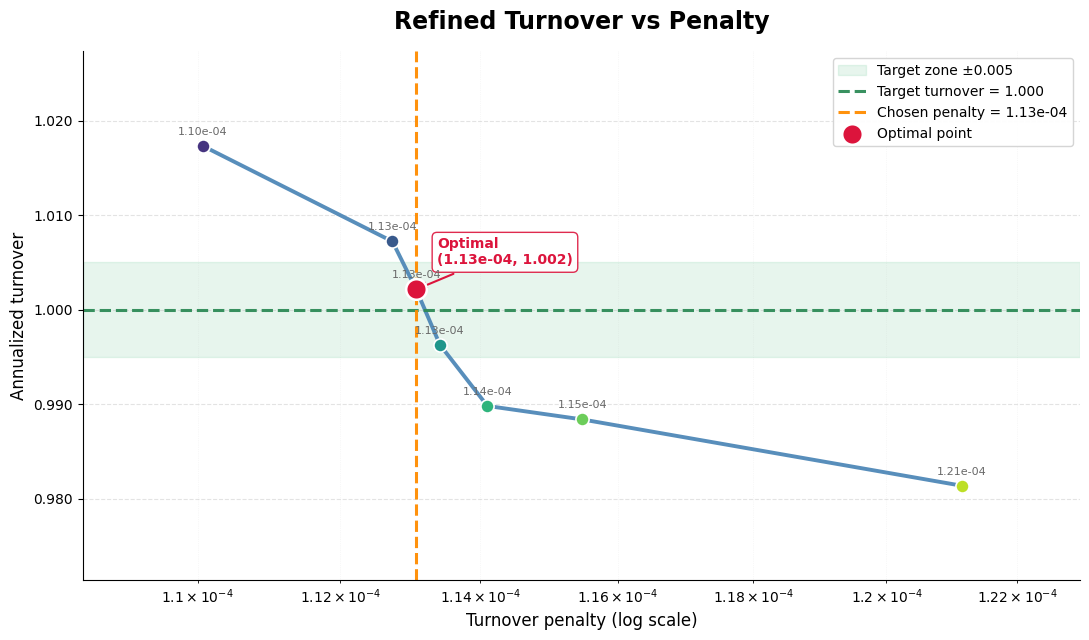

Rebalancing date: 2002-01-31
Rebalancing date: 2002-04-30
Rebalancing date: 2002-07-31
Rebalancing date: 2002-10-31
Rebalancing date: 2003-01-31
Rebalancing date: 2003-04-30
Rebalancing date: 2003-07-31
Rebalancing date: 2003-10-31
Rebalancing date: 2004-01-31
Rebalancing date: 2004-04-30
Rebalancing date: 2004-07-31
Rebalancing date: 2004-10-31
Rebalancing date: 2005-01-31
Rebalancing date: 2005-04-30
Rebalancing date: 2005-07-31
Rebalancing date: 2005-10-31
Rebalancing date: 2006-01-31
Rebalancing date: 2006-04-30
Rebalancing date: 2006-07-31
Rebalancing date: 2006-10-31
Rebalancing date: 2007-01-31
Rebalancing date: 2007-04-30
Rebalancing date: 2007-07-31
Rebalancing date: 2007-10-31
Rebalancing date: 2008-01-31
Rebalancing date: 2008-04-30
Rebalancing date: 2008-07-31
Rebalancing date: 2008-10-31
Rebalancing date: 2009-01-31
Rebalancing date: 2009-04-30
Rebalancing date: 2009-07-31
Rebalancing date: 2009-10-31
Rebalancing date: 2010-01-31
Rebalancing date: 2010-04-30
Rebalancing da

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.ticker import FuncFormatter

# Keep only the closest points to the optimal penalty
n_points = 7

deep_df_plot = (
    deep_df
    .assign(distance=lambda df: abs(df['turnover_penalty'] - best_turnover_penalty))
    .sort_values('distance')
    .head(n_points)
    .sort_values('turnover_penalty')
    .reset_index(drop=True)
)

x = deep_df_plot['turnover_penalty'].values
y = deep_df_plot['annualized_turnover'].values

# Colormap for points
colors = cm.viridis(np.linspace(0.15, 0.9, len(deep_df_plot)))

fig, ax = plt.subplots(figsize=(11, 6.5))

# Soft band around target turnover
target_band = 0.005
ax.axhspan(
    target_turnover - target_band,
    target_turnover + target_band,
    color='mediumseagreen',
    alpha=0.12,
    label=f'Target zone ±{target_band:.3f}'
)

# Main line
ax.plot(
    x,
    y,
    color='steelblue',
    linewidth=2.8,
    alpha=0.9,
    zorder=2
)

# Scatter points with gradient colors
for i in range(len(x)):
    ax.scatter(
        x[i],
        y[i],
        s=90,
        color=colors[i],
        edgecolor='white',
        linewidth=1.2,
        zorder=3
    )

# Reference lines
ax.axhline(
    target_turnover,
    color='seagreen',
    linestyle='--',
    linewidth=2.2,
    alpha=0.95,
    label=f'Target turnover = {target_turnover:.3f}'
)

ax.axvline(
    best_turnover_penalty,
    color='darkorange',
    linestyle='--',
    linewidth=2.2,
    alpha=0.95,
    label=f'Chosen penalty = {best_turnover_penalty:.2e}'
)

# Highlight optimal point
ax.scatter(
    best_turnover_penalty,
    best_turnover_deep,
    s=220,
    color='crimson',
    edgecolor='white',
    linewidth=1.8,
    zorder=5,
    label='Optimal point'
)

# Annotation for optimal point
ax.annotate(
    f'Optimal\n({best_turnover_penalty:.2e}, {best_turnover_deep:.3f})',
    xy=(best_turnover_penalty, best_turnover_deep),
    xytext=(15, 18),
    textcoords='offset points',
    fontsize=10,
    color='crimson',
    weight='bold',
    bbox=dict(boxstyle='round,pad=0.35', fc='white', ec='crimson', alpha=0.9),
    arrowprops=dict(arrowstyle='->', color='crimson', lw=1.5)
)

# Optional: annotate each point lightly
for i, (xi, yi) in enumerate(zip(x, y)):
    ax.annotate(
        f'{xi:.2e}',
        (xi, yi),
        textcoords='offset points',
        xytext=(0, 8),
        ha='center',
        fontsize=8,
        color='dimgray'
    )

ax.set_xscale('log')

# Better zoom
x_pad_left = x.min() * 0.985
x_pad_right = x.max() * 1.015
ax.set_xlim(x_pad_left, x_pad_right)

ymin = min(y.min(), target_turnover) - 0.01
ymax = max(y.max(), target_turnover) + 0.01
ax.set_ylim(ymin, ymax)

# Labels and title
ax.set_title(
    'Refined Turnover vs Penalty',
    fontsize=17,
    fontweight='bold',
    pad=16
)
ax.set_xlabel('Turnover penalty (log scale)', fontsize=12)
ax.set_ylabel('Annualized turnover', fontsize=12)

# Cleaner y-axis formatting
ax.yaxis.set_major_formatter(FuncFormatter(lambda val, _: f'{val:.3f}'))

# Grid styling
ax.grid(True, which='major', linestyle='--', linewidth=0.8, alpha=0.35)
ax.grid(True, which='minor', linestyle=':', linewidth=0.5, alpha=0.18)

# Clean spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Legend
leg = ax.legend(
    loc='best',
    frameon=True,
    fancybox=True,
    shadow=False,
    framealpha=0.95,
    fontsize=10
)
leg.get_frame().set_edgecolor('lightgray')

plt.tight_layout()
plt.show()

# Re-run full backtest with selected penalty
bs.optimization = MaxSharpe(
    covariance=Covariance(method='pearson'),
    expected_return=ExpectedReturn(method='geometric'),
    solver_name='cvxopt',
    turnover_penalty=float(best_turnover_penalty),
    risk_aversion=1.0,
    max_iter=refinement_max_iter,
    tol=refinement_tol,
)

bt_ms = Backtest()
bt_ms.run(bs=bs)

return_series = search_return_series
to_ms = bt_ms.strategy.turnover(return_series=return_series)
annualized_turnover_full = to_ms.iloc[1:].mean() * search_rebal_per_year

print(f'Penalty used in the full backtest: {best_turnover_penalty:.8f}')
print(f'Annualized turnover on the full backtest: {annualized_turnover_full:.4f}')

## 4. Simulation and Descriptive Statistics

(3 points)

- Simulate the portfolio returns from your MaxSharpe backtest. Use fixed costs of 1% per annum (p.a.) and variable costs of 0.3% p.a.
- Plot the cumulated returns of the MaxSharpe strategy together with those of the SPI Index.
- Plot the turnover of your MaxSharpe strategy over time.
- Print the annualized turnover (computed as the average turnover over the backtest multiplied by the number of rebalancing per year) for your MaxSharpe strategy.
- Create and print a table with descriptive performance statistics for your MaxSharpe strategy and the SPI Index.


<Axes: title={'center': 'Cumulative Performance'}>

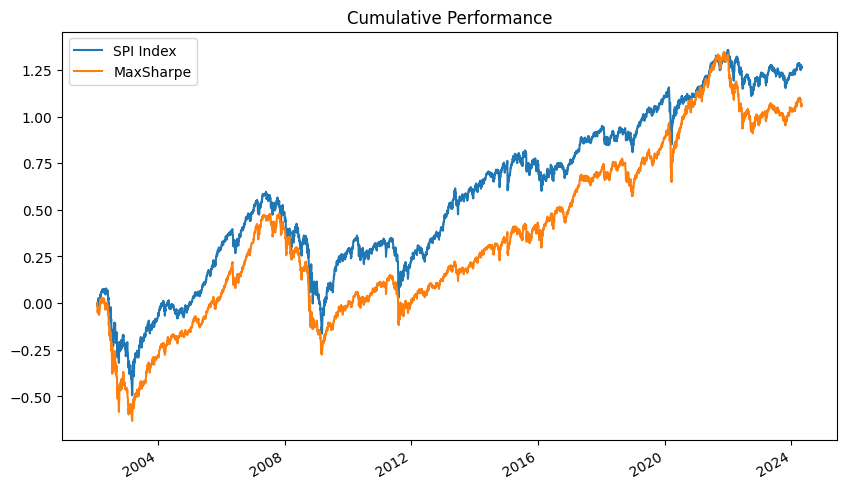

In [13]:
# Use the assignment cost assumptions for the final strategy simulation.
fixed_costs = 0.01
variable_costs = 0.003
return_series = bs.data.get_return_series(weekdays_only=False)

# Rebuild the strategy return series leg by leg between rebalance dates.
# We do it here because Strategy.simulate() currently misaligns costs.
sim_segments = []
sim_rebdates = bt_ms.strategy.get_rebalancing_dates()

for rebdate in sim_rebdates:
    next_rebdate = (
        sim_rebdates[sim_rebdates.index(rebdate) + 1]
        if rebdate < sim_rebdates[-1]
        else return_series.index[-1]
    )

    # Hold the portfolio chosen on rebalance date until the next rebalance.
    portfolio = bt_ms.strategy.get_portfolio(rebdate)
    w_float = portfolio.float_weights(
        return_series=return_series,
        end_date=next_rebdate,
        rescale=False,
    )
    sim_segments.append(w_float.sum(axis=1).pct_change(1))

sim_ms = pd.concat(sim_segments).dropna()

# Charge variable trading costs on the dates where turnover occurs.
turnover_for_costs = bt_ms.strategy.turnover(
    return_series=return_series,
    rescale=False,
)
varcost = turnover_for_costs * variable_costs
sim_ms.iloc[0] -= varcost.iloc[0]
sim_ms.loc[varcost.index[1:]] -= varcost.iloc[1:].to_numpy()

# Convert annual fixed costs into the actual gap between observations.
n_days = (
    sim_ms.index[1:] - sim_ms.index[:-1]
).to_numpy().astype('timedelta64[D]').astype(int)
fixcost = (1 + fixed_costs) ** (n_days / 252) - 1
sim_ms.iloc[1:] -= fixcost

# Compare the strategy and benchmark on the same date range.
sim = pd.concat({
    'bm': bs.data.bm_series,
    'ms': sim_ms,
}, axis = 1).dropna()

sim.columns = ['SPI Index', 'MaxSharpe']

# Plot the cumulative returns of the strategy and the benchmark
np.log(1 + sim).cumsum().plot(title='Cumulative Performance', figsize=(10, 6))

<Axes: title={'center': 'Turnover'}>

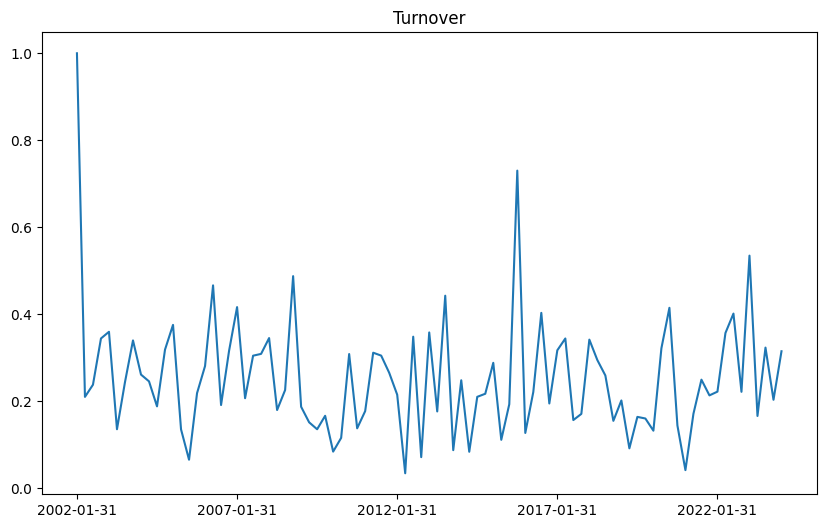

In [14]:
# Turnover
to_ms = bt_ms.strategy.turnover(return_series=return_series)
to_ms.plot(title='Turnover', figsize = (10, 6))

In [15]:
# Turn average turnover per rebalance into an annualized percentage.
rebdates_dt = pd.to_datetime(rebdates)
rebal_per_year = 365.25 / np.median(
    np.diff(rebdates_dt).astype('timedelta64[D]').astype(int)
)
to_pa = to_ms.iloc[1:].mean() * rebal_per_year * 100
print(f"The annualized turnover is: {to_pa}%")


The annualized turnover is: 97.564259114426%


In [16]:
# Small helpers for the summary table below.

def annualized_return(series, periods_per_year=252):
    series = series.dropna()
    if series.empty:
        return np.nan
    wealth = (1 + series).prod()
    return wealth ** (periods_per_year / len(series)) - 1

def cumulative_return(series):
    series = series.dropna()
    if series.empty:
        return np.nan
    return (1 + series).prod() - 1

def annualized_volatility(series, periods_per_year=252):
    series = series.dropna()
    if len(series) < 2:
        return np.nan
    return series.std(ddof=1) * np.sqrt(periods_per_year)

def sharpe_ratio(series, periods_per_year=252):
    vol = annualized_volatility(series, periods_per_year=periods_per_year)
    if pd.isna(vol) or vol == 0:
        return np.nan
    return series.dropna().mean() / series.dropna().std(ddof=1) * np.sqrt(periods_per_year)

def max_drawdown(series):
    series = series.dropna()
    if series.empty:
        return np.nan
    # Drawdown is measured from the running peak of cumulative wealth.
    wealth_index = (1 + series).cumprod()
    running_peak = wealth_index.cummax()
    drawdown = wealth_index / running_peak - 1
    return drawdown.min()

# Compute the same set of metrics for the benchmark and the strategy.
stats = {}
for column in sim.columns:
    series = sim[column].dropna()
    stats[column] = {
        'Annual Return': annualized_return(series),
        'Cumulative Return': cumulative_return(series),
        'Annual Volatility': annualized_volatility(series),
        'Sharpe Ratio': sharpe_ratio(series),
        'Max Drawdown': max_drawdown(series),
    }

stats_df = pd.DataFrame(stats).round(4)
display(stats_df)


,SPI Index,MaxSharpe
Annual Return,0.0556,0.0466
Cumulative Return,2.5325,1.8891
Annual Volatility,0.1647,0.1442
Sharpe Ratio,0.4114,0.3880
Max Drawdown,-0.5325,-0.5300
